# k-NN Regression - sklearn in Action

> **MLCourse · Machine Learning · supervised · regression**

End-to-end workflow: baseline → cross-validated k sweep → weights comparison
→ honest held-out test metrics. Real data: **California housing** (20,640
census blocks, 8 features, target = median house value per block). We work
on a 4,000-row subsample so every fit stays snappy.

### What you'll learn
- `Pipeline(StandardScaler + KNeighborsRegressor)` as the non-negotiable default
- Reading a **k sweep CV curve** to pick `n_neighbors` with evidence
- `weights="uniform"` vs `"distance"` - does it matter here?
- Reporting MAE / RMSE / R² and what each one says

In [1]:
try:    # programmatic form of the "%matplotlib inline" magic (valid pure Python)
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:   # running as plain script -> nothing to do
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor                 # "predict the mean" yardstick
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
ML_ROOT = Path.cwd()                                     # walk UP to the ML folder
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

# California housing comes bundled with sklearn; we cache it ONCE as a real CSV
csv = ML_ROOT / "data" / "california_housing.csv"
if not csv.exists():                                     # first run on this machine?
    from sklearn.datasets import fetch_california_housing
    fetch_california_housing(as_frame=True).frame.to_csv(csv, index=False)  # freeze frame
    print("cached ->", csv.name)
else:
    print("using local ->", csv.name)
cal = pd.read_csv(csv)

df = cal.sample(n=4000, random_state=42).reset_index(drop=True)  # reproducible subsample
print(df.shape)                                          # (4000 rows, 9 columns incl. target)

using local -> california_housing.csv
(4000, 9)


### 1. Quick look before modeling

Three checks we ALWAYS run first: what does the **target** look like, which
features move with it, and how correlated are features with each other.

        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
count  4000.00   4000.00   4000.00    4000.00     4000.00   4000.00   4000.00   
mean      3.83     28.74      5.41       1.10     1424.86      2.96     35.59   
std       1.88     12.52      2.83       0.62     1120.64      1.78      2.13   
min       0.50      1.00      0.85       0.50        8.00      1.26     32.54   
25%       2.55     18.00      4.39       1.00      782.00      2.43     33.93   
50%       3.50     29.00      5.19       1.05     1160.00      2.82     34.23   
75%       4.65     37.00      6.00       1.10     1723.00      3.29     37.70   
max      15.00     52.00    132.53      34.07    16122.00     83.17     41.81   

       Longitude  MedHouseVal  
count    4000.00      4000.00  
mean     -119.52         2.06  
std         1.99         1.15  
min      -124.19         0.15  
25%      -121.69         1.19  
50%      -118.47         1.79  
75%      -118.00         2.63  
max      -114.

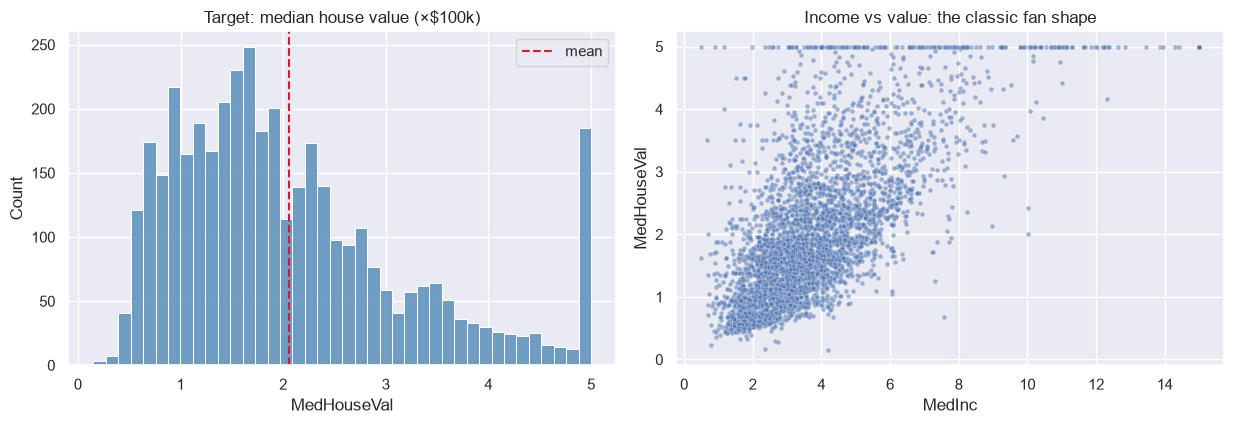

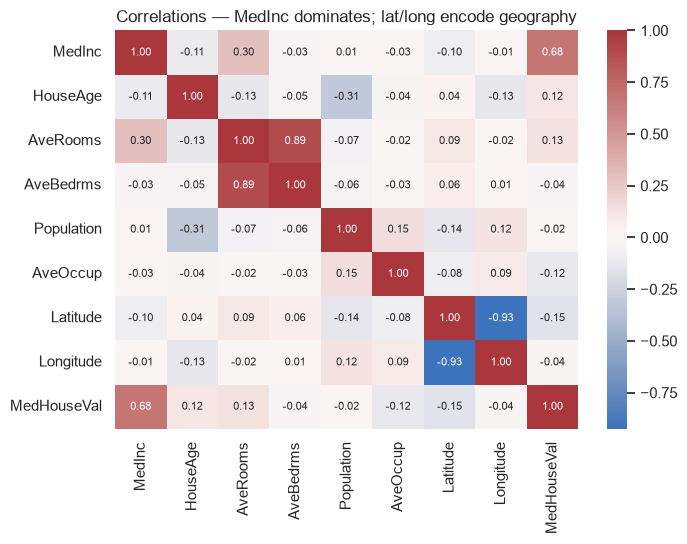

In [2]:
print(df.describe().round(2))                            # ranges scream "scale me!"

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
sns.histplot(df["MedHouseVal"], bins=40, ax=axes[0], color="steelblue")  # target shape
axes[0].set_title("Target: median house value (×$100k)")
axes[0].axvline(df["MedHouseVal"].mean(), color="crimson", ls="--", label="mean")
axes[0].legend()
sns.scatterplot(data=df, x="MedInc", y="MedHouseVal", s=12, alpha=.5,
                ax=axes[1])                              # strongest known driver
axes[1].set_title("Income vs value: the classic fan shape")
plt.tight_layout(); plt.show()

corr = df.corr(numeric_only=True)                        # pairwise linear correlation
plt.figure(figsize=(7.2, 5.6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, annot_kws={"size": 8})
plt.title("Correlations - MedInc dominates; lat/long encode geography")
plt.tight_layout(); plt.show()

### 2. Data processing & baseline

Split first (80/20), then build a Pipeline that scales INSIDE it - so each
CV fold fits its own scaler on train-fold rows only (no leakage).
Baselines keep us honest:
- `DummyRegressor` = predict the training mean (what R²=0 means)
- default k-NN (k=5, uniform) = our starting distance model

In [3]:
X = df.drop(columns="MedHouseVal")       # 8 features
y = df["MedHouseVal"]                    # target in units of $100k

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)    # shuffles folds for i.i.d.-ish splits

dummy = DummyRegressor(strategy="mean").fit(X_tr, y_tr)  # trivial yardstick model
knn_pipe = Pipeline([("sc", StandardScaler()),           # z-score EVERY feature
                     ("knn", KNeighborsRegressor())])    # defaults: k=5, uniform

r2_dum = cross_val_score(dummy, X_tr, y_tr, cv=cv, scoring="r2").mean()
r2_knn = cross_val_score(knn_pipe, X_tr, y_tr, cv=cv, scoring="r2").mean()
rmse_knn = -cross_val_score(knn_pipe, X_tr, y_tr, cv=cv,
                            scoring="neg_root_mean_squared_error").mean()

print(f"Dummy mean   : CV R² = {r2_dum:.3f}                      <- floor")
print(f"kNN k=5 unif.: CV R² = {r2_knn:.3f}, RMSE = {rmse_knn:.3f}")

Dummy mean   : CV R² = -0.001                      <- floor
kNN k=5 unif.: CV R² = 0.674, RMSE = 0.655


> ⚠️ **Common pitfall:** comparing models with different scalers *outside* a
Pipeline leaks statistics across folds. Keep scaler+model glued in one object
and hand THAT to `cross_val_score`.

### 3. Choosing k - the CV sweep curve

Sweep k from memorization (1) toward global averaging (160), scoring each by
5-fold CV. We plot BOTH R² (higher=better) and RMSE (lower=better); expect an
upside-down-U for R²: small k overfits, huge k underfits.

k=  1: R²=0.513  RMSE=0.799


k=  3: R²=0.654  RMSE=0.673


k=  5: R²=0.674  RMSE=0.655


k= 10: R²=0.678  RMSE=0.650


k= 20: R²=0.681  RMSE=0.648


k= 40: R²=0.659  RMSE=0.670


k= 80: R²=0.618  RMSE=0.710


k=160: R²=0.547  RMSE=0.773

best k by CV R² -> 20


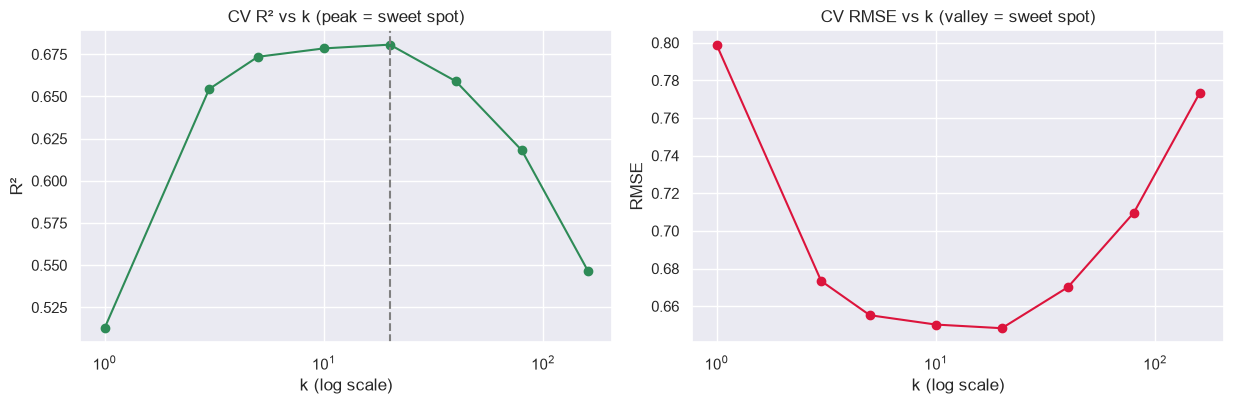

In [4]:
ks = [1, 3, 5, 10, 20, 40, 80, 160]                      # log-spaced-ish ladder of ks
r2_means, rmse_means = [], []                             # collect CV scores per k
for kk in ks:                                             # one pipeline per candidate
    pipe = Pipeline([("sc", StandardScaler()),
                     ("knn", KNeighborsRegressor(n_neighbors=kk))])
    r2_means.append(cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="r2").mean())
    rmse_means.append(-cross_val_score(pipe, X_tr, y_tr, cv=cv,
                                       scoring="neg_root_mean_squared_error").mean())
    print(f"k={kk:>3}: R²={r2_means[-1]:.3f}  RMSE={rmse_means[-1]:.3f}")

best_k = ks[int(np.argmax(r2_means))]                     # k with best mean CV R²
print(f"\nbest k by CV R² -> {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].plot(ks, r2_means, "o-", color="seagreen"); axes[0].set_xscale("log")
axes[0].axvline(best_k, ls="--", color="gray"); axes[0].set_title("CV R² vs k (peak = sweet spot)")
axes[0].set_xlabel("k (log scale)"); axes[0].set_ylabel("R²")
axes[1].plot(ks, rmse_means, "o-", color="crimson"); axes[1].set_xscale("log")
axes[1].set_title("CV RMSE vs k (valley = sweet spot)")
axes[1].set_xlabel("k (log scale)"); axes[1].set_ylabel("RMSE")
plt.tight_layout(); plt.show()

### 4. Does `weights` matter? uniform vs distance

With `weights="distance"` a neighbor at d contributes `1/d` instead of 1, so
sparse regions lean on their closest rows. Same best-k neighborhood, two rules:

In [5]:
rows = []
for w in ["uniform", "distance"]:                         # the two voting rules
    pipe = Pipeline([("sc", StandardScaler()),
                     ("knn", KNeighborsRegressor(n_neighbors=best_k, weights=w))])
    r2 = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="r2").mean()
    rmse = -cross_val_score(pipe, X_tr, y_tr, cv=cv,
                            scoring="neg_root_mean_squared_error").mean()
    rows.append({"weights": w, "cv_R2": round(r2, 4), "cv_RMSE": round(rmse, 4)})
wtab = pd.DataFrame(rows)
print(wtab.to_string(index=False))

 weights  cv_R2  cv_RMSE
 uniform 0.6807   0.6483
distance 0.6869   0.6420


> 💡 **Pro tip:** when two settings are within noise (~±0.005 R²), prefer the
SIMPLER (`uniform`). Fewer moving parts = fewer surprises on new data.

### 5. Final evaluation on the untouched test set

Refit the winner on all training rows, predict once on the held-out 800
blocks, and report the three standard regression numbers:

      metric  value
 MAE ($100k)  0.459
RMSE ($100k)  0.649
          R²  0.663


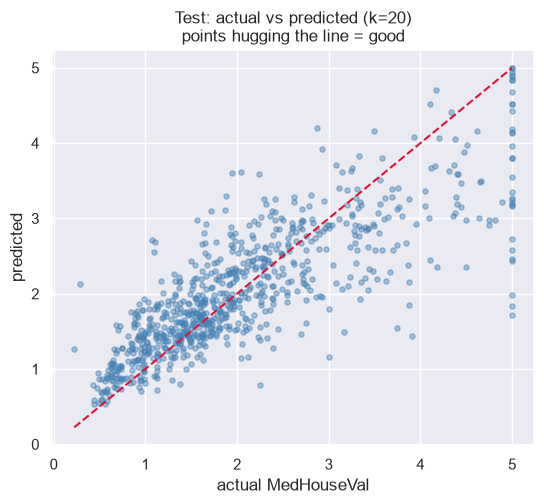

In [6]:
final = Pipeline([("sc", StandardScaler()),
                  ("knn", KNeighborsRegressor(n_neighbors=best_k,
                                              weights=wtab.loc[wtab.cv_R2.idxmax(), "weights"]))])
final.fit(X_tr, y_tr)                                    # "training" stores scaled rows
pred = final.predict(X_te)                               # average neighbors per block

mae = mean_absolute_error(y_te, pred)                    # avg $ error, robust to outliers
rmse = mean_squared_error(y_te, pred) ** .5              # punishes big misses harder
r2 = r2_score(y_te, pred)                                # variance explained vs mean-only
print(pd.DataFrame({"metric": ["MAE ($100k)", "RMSE ($100k)", "R²"],
                    "value": [round(mae, 3), round(rmse, 3), round(r2, 3)]}).to_string(index=False))

plt.figure(figsize=(5.6, 5.2))
plt.scatter(y_te, pred, s=14, alpha=.45, color="steelblue")     # each dot = one block
lims = [y_te.min(), y_te.max()]
plt.plot(lims, lims, "--", color="crimson")                     # perfect-prediction diagonal
plt.xlabel("actual MedHouseVal"); plt.ylabel("predicted")
plt.title(f"Test: actual vs predicted (k={best_k})\npoints hugging the line = good")
plt.tight_layout(); plt.show()

### Findings
1. Median income alone carries most of the signal; k-NN picks it up through
   local neighborhoods without any feature engineering.
2. The k curve peaks around mid-range k - both extremes lose clearly.
3. Distance weighting helps only marginally here; density is fairly even.
4. Errors grow at the TOP of the price range (expensive coastal blocks vary
   more locally than cheap inland ones).

### Summary & key takeaways

- Glue scaler + k-NN into ONE Pipeline - scaling is part of the model, and
  Pipelines make CV leakage-proof.
- Pick k with a CV sweep: peak R² / valley RMSE, never train-set performance.
- Report MAE (typical miss), RMSE (punishes big misses), R² (vs mean-only);
  each tells a different story.
- k-NN is instant to "fit" but pays at predict time - fine at n=4,000,
  painful at n=2,000,000 (see the README's ✅/❌ list).